In [ ]:
# IMPORTING LIBRARIES
from datetime import datetime 
import pandas as pd 
import matplotlib.pyplot as plt

Graph can only be displayed between 6 PM and 9 PM IST


C:\Users\PS SANTHI\AppData\Local\Temp\ipykernel_23792\646733143.py:92: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


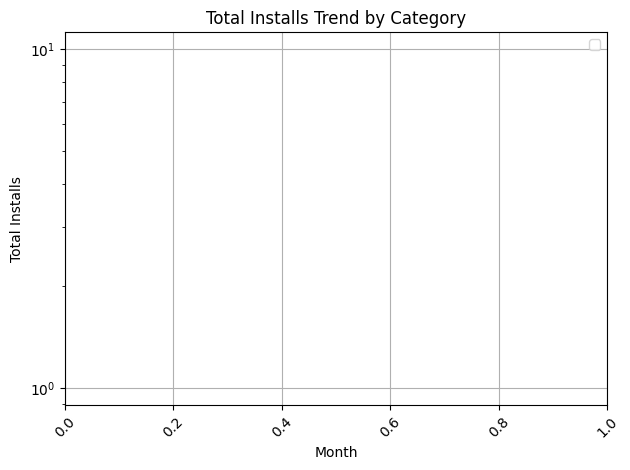

In [ ]:
# Get current hour

current_hour = datetime.now().hour

# Time Condition (6 PM to 9 PM IST)

if current_hour < 18 or current_hour >= 21:
    print ("Graph can only be displayed between 6 PM and 9 PM IST")
else:
    
    # LOADING DATA
    
    df = pd.read_csv("E:/DATASETS/Play Store Data (1).csv")
    
    # CLEANING DATA
    
    # Remove null values
    df =df.dropna()
    
    # Remove apps starting with X,Y,Z
    df = df[~df['App'].str.lower().str.startswith(('x','y','z'))]
    
    # Remove apps containing letter S
    df = df[~df['App'].str.contains('s', case= False)]
    
    # Category should start with E,C, or B
    df = df[df['Category'].str.startswith(('E','C','B'))]
    
    # Reviews should be greater than 500
    df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')
    df = df[df['Reviews'] > 500]
    
    # Clean Installs column
    df['Installs'] = df['Installs'].str.replace('+', '')
    df['Installs'] = df['Installs'].str.replace(',', '')
    df['Installs'] = pd.to_numeric(df['Installs'])
    
    # Convert date column
    df['Last Updated'] = pd.to_datetime(df['Last Updated'])
    
    # TRANSLATE CATEGORY NAMES
    
    df['Category'] = df['Category'].replace({
        'BEAUTY': 'सौंदर्य',             # Hindi
        'BUSINESS': 'வணிகம்',           # Tamil
        'DATING': 'Partnersuche'       # German
    })
    
    # CREATE MONTH COLUMN
    
    df['Month'] = df['Last Updated'].dt.to_period('M')
    
    # GROUP DATA
    
    grouped_data = df.groupby(['Month','Category'])['Installs'].sum().reset_index()
    
    # PLOTTING GRAPH 
    
    plt.Figure(figsize=(12,6))
    
    for category in grouped_data['Category'].unique():
        category_data = grouped_data[grouped_data['Category'] == category]
        
        # Plotting Line Chart
        plt.plot(
            category_data['Month'].astype(str),
            category_data['Installs'],
            marker= 'o',
            label= category
        )   
        
        # Find growth percentage
        growth = category_data['Installs'].pct_change()
        
        #Highlight growth > 20%
        for i in range(1, len(category_data)):
            if growth.iloc[i] > 0.20:
                
                plt.fill_between(
                    category_data['Month'].astype(str).iloc[i-1:i+1],
                    category_data['Installs'].iloc[i-1:i+1],
                    alpha=0.3
                )
                
    # GRAPH LABELS
    
plt.title("Total Installs Trend by Category")
plt.xlabel("Month")
plt.ylabel("Total Installs")

plt.xticks(rotation=45)

plt.legend()

plt.grid(True)

# Better visualization
plt.yscale('log')
plt.tight_layout()
plt.show()